In [1]:
!kaggle datasets download algozee/employee-salary-prediction-dataset

Dataset URL: https://www.kaggle.com/datasets/algozee/employee-salary-prediction-dataset
License(s): apache-2.0
employee-salary-prediction-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [2]:
!unzip -q employee-salary-prediction-dataset.zip
!ls

employee-salary-prediction-dataset.zip	sample_data
job_salary_prediction_dataset.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, PowerTransformer, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.decomposition import PCA

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from scipy import stats

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

np.random.seed(42)

In [4]:
df = pd.read_csv("job_salary_prediction_dataset.csv")
df.head(2)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764


In [5]:
df.shape

(250000, 10)

#### Quick EDA

In [6]:
display(df.describe(exclude="object").T)

print("\nMissing values per column:")
display(df.isna().sum())

,count,mean,std,min,25%,50%,75%,max
experience_years,250000.0,10.005408,6.060602,0.0,5.0,10.0,15.0,20.0
skills_count,250000.0,9.997812,5.479288,1.0,5.0,10.0,15.0,19.0
certifications,250000.0,2.491928,1.706475,0.0,1.0,2.0,4.0,5.0
salary,250000.0,145718.080524,37407.952729,31867.0,119358.0,143453.0,169492.0,333046.0



Missing values per column:


,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


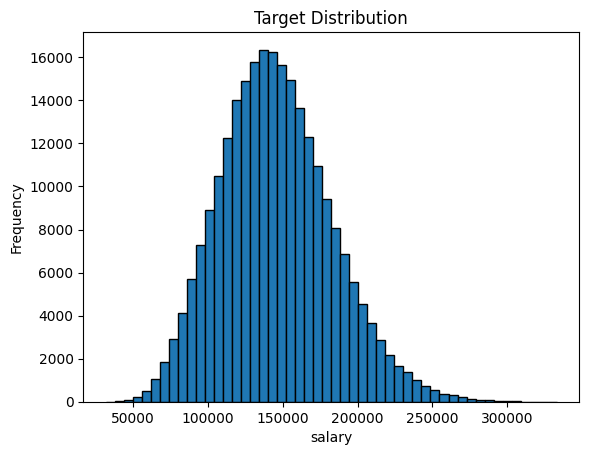

In [7]:
plt.figure()
plt.hist(df["salary"], bins=50, edgecolor="black")
plt.title("Target Distribution")
plt.xlabel("salary")
plt.ylabel("Frequency")
plt.show()

In [8]:
cols = df.select_dtypes("object").columns.tolist()
cols

['job_title',
 'education_level',
 'industry',
 'company_size',
 'location',
 'remote_work']

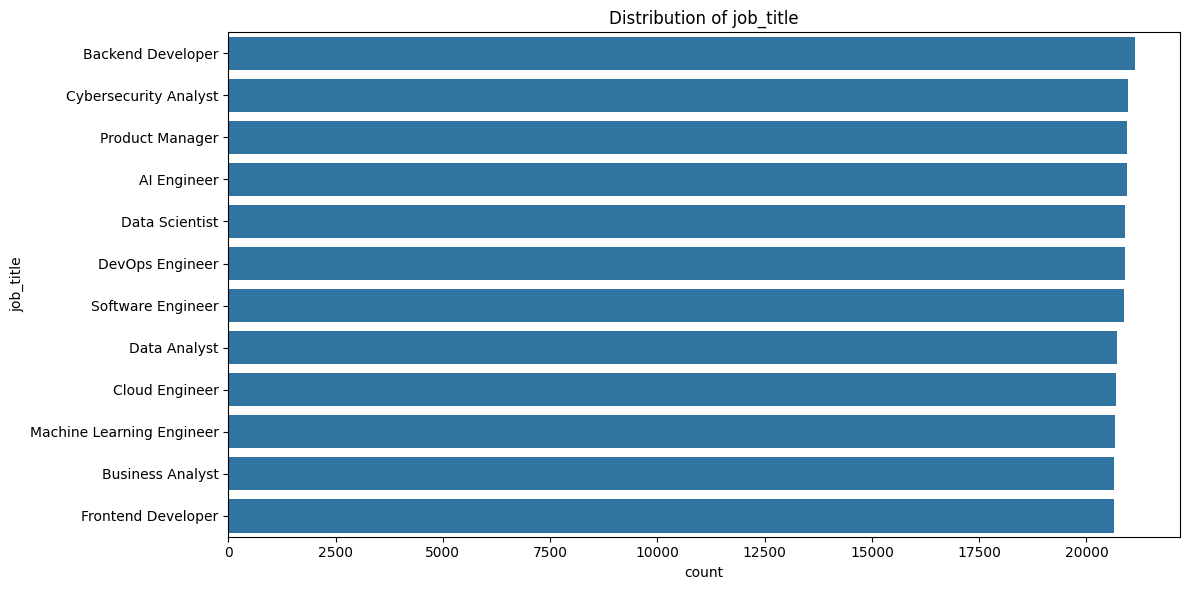

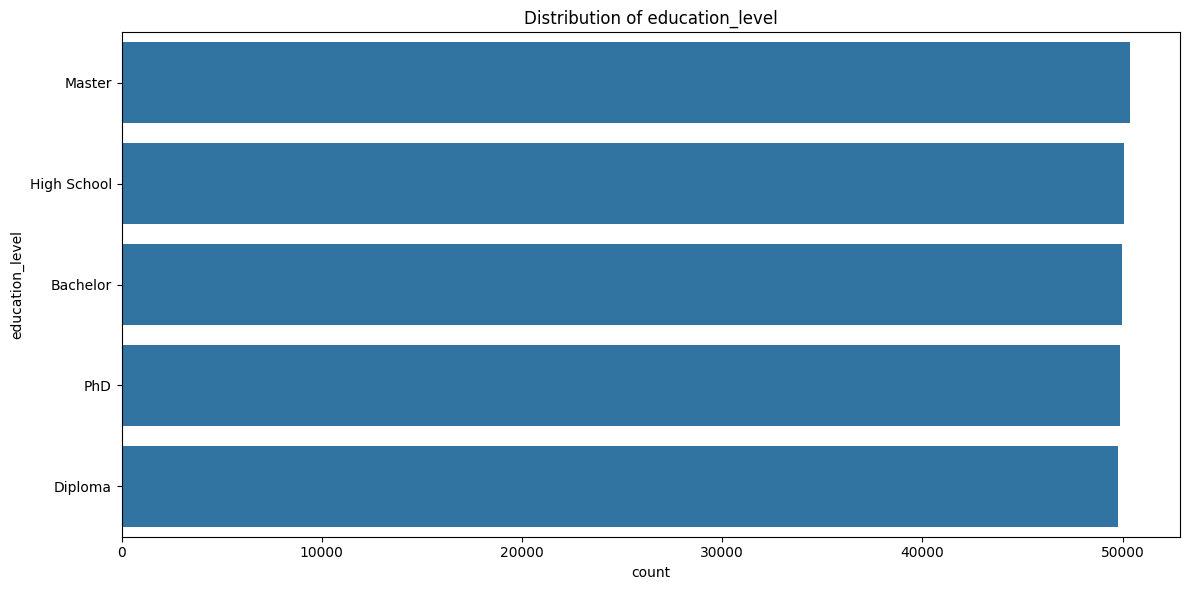

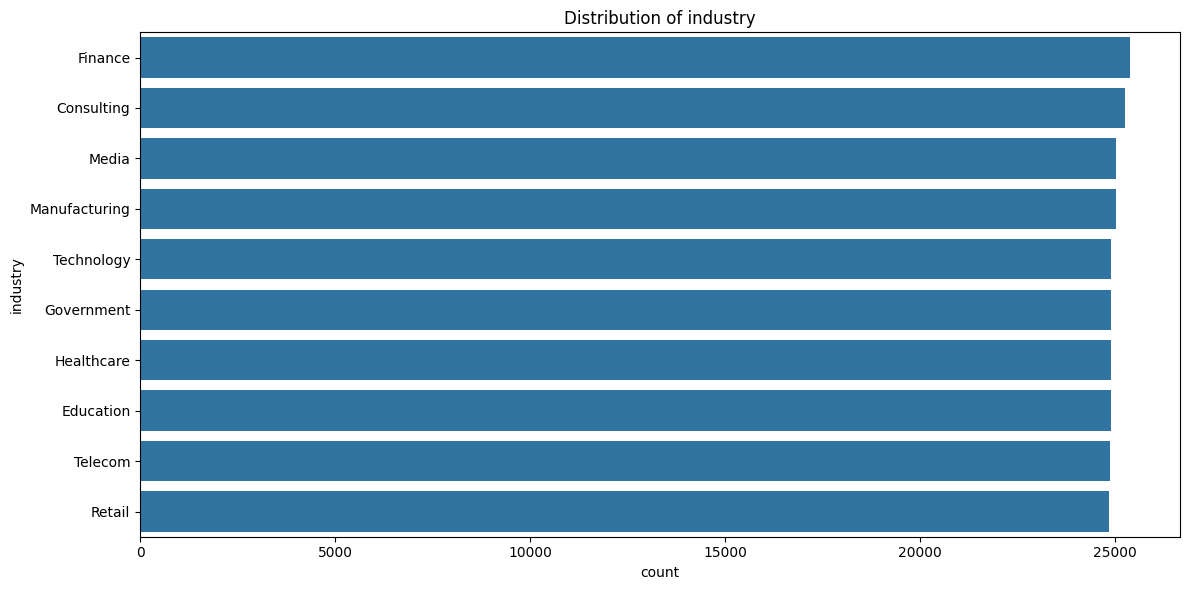

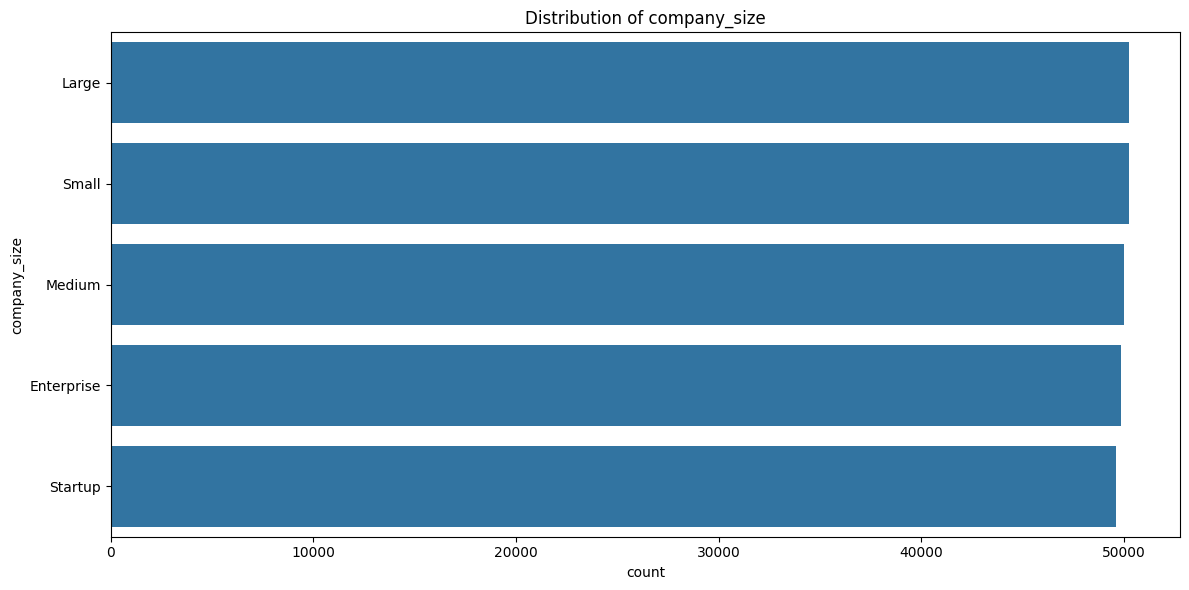

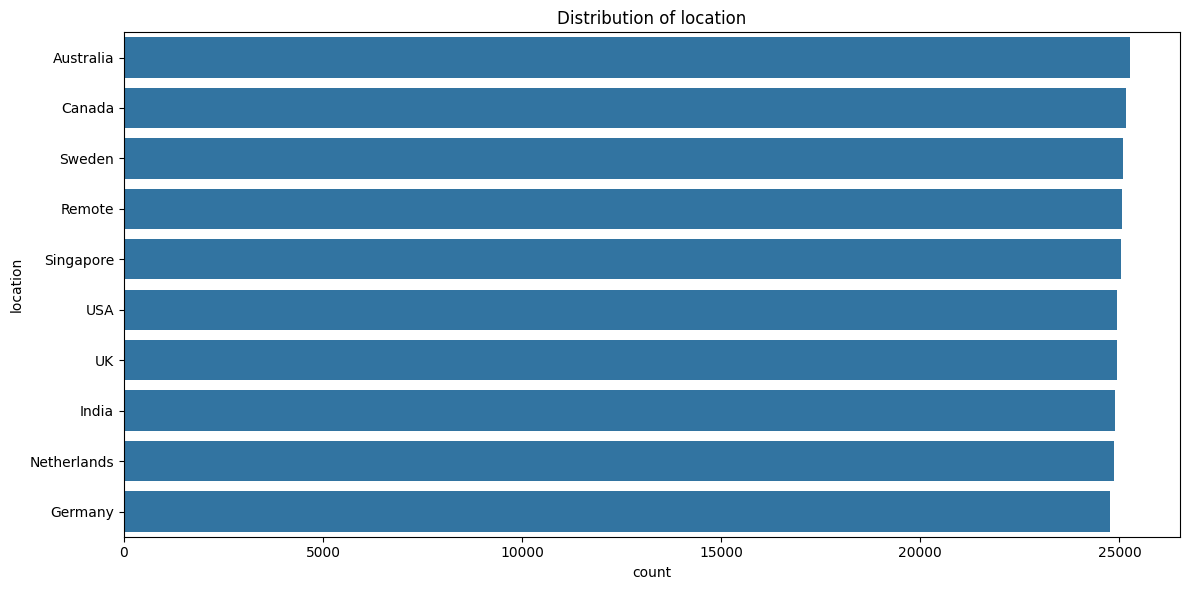

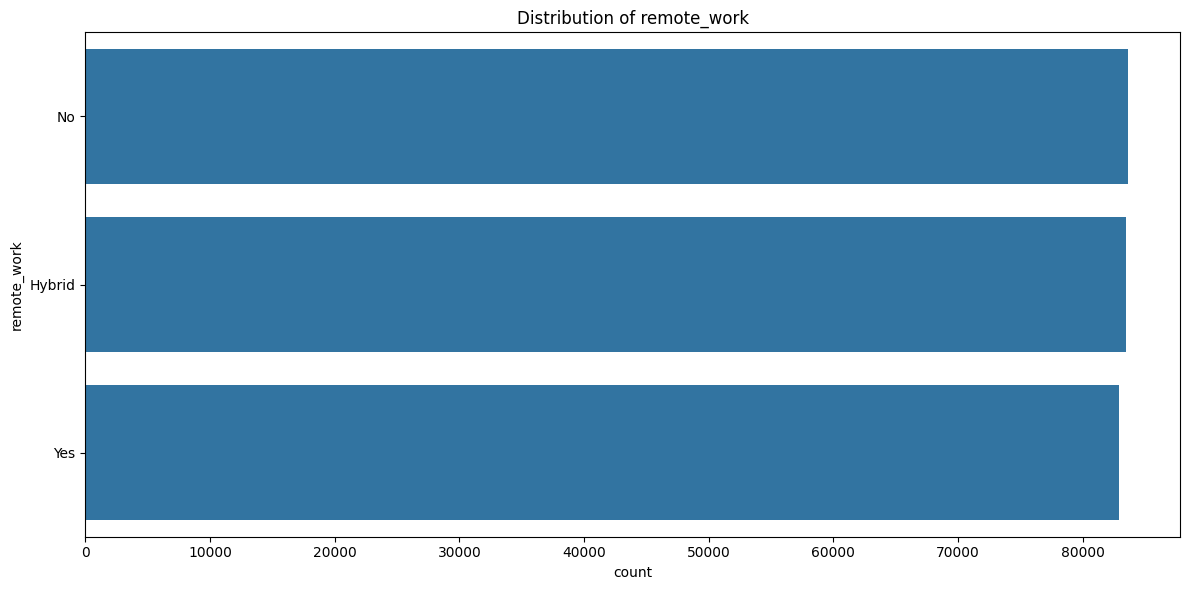

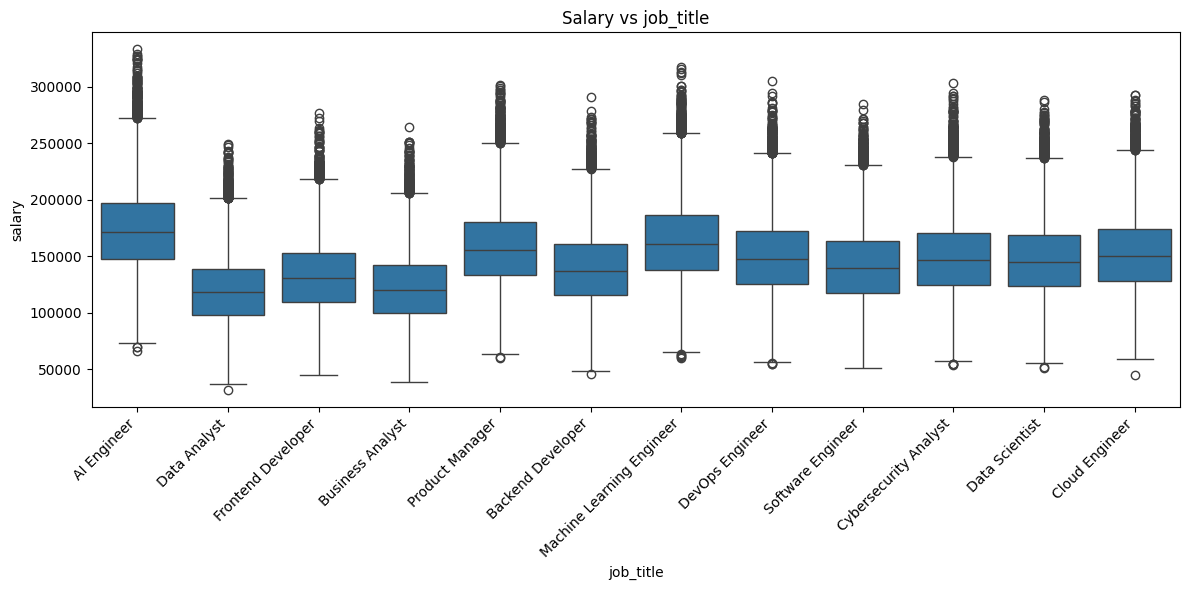

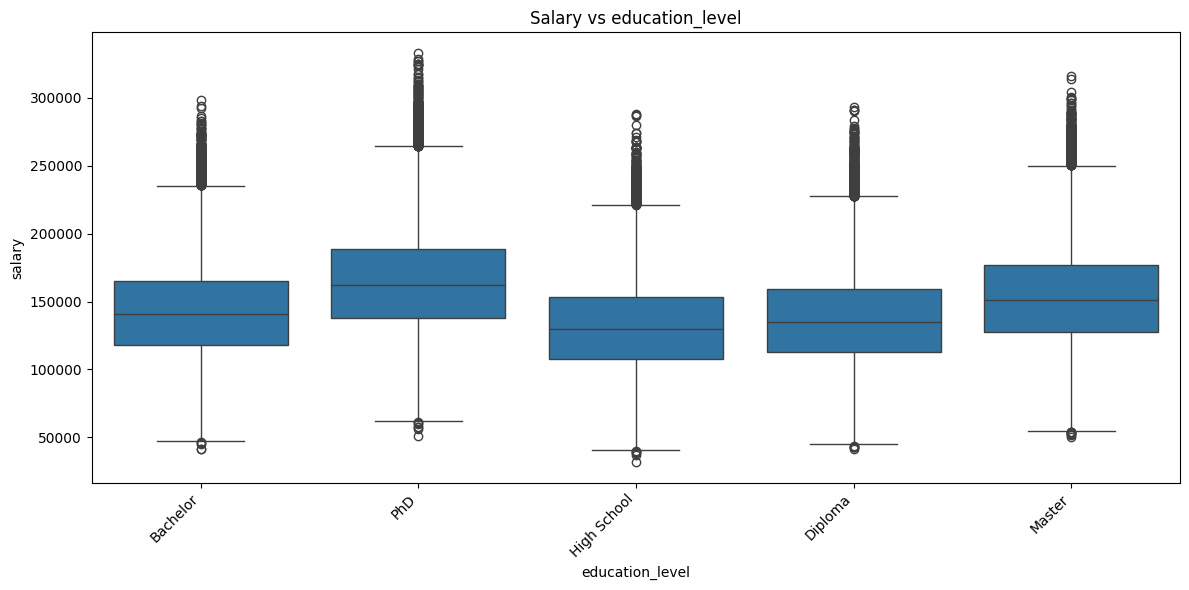

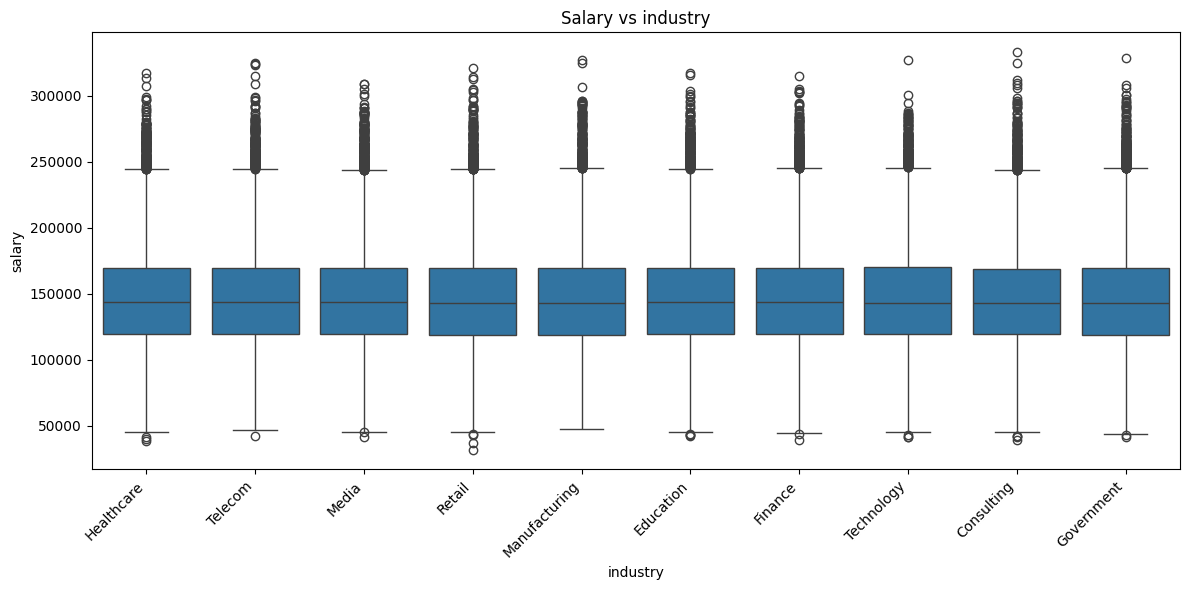

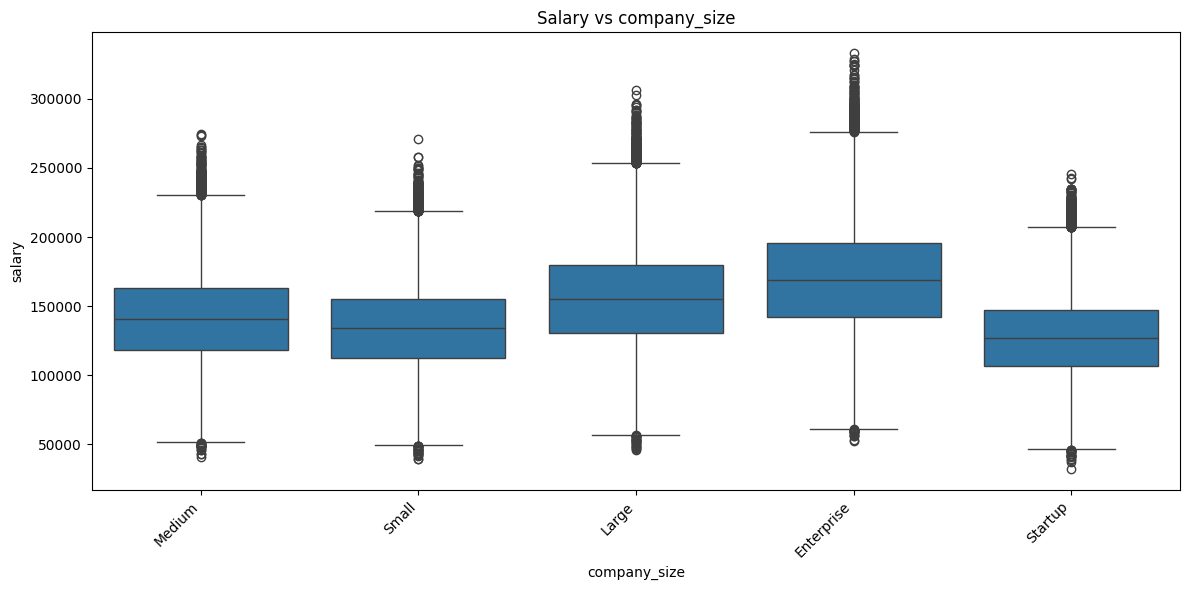

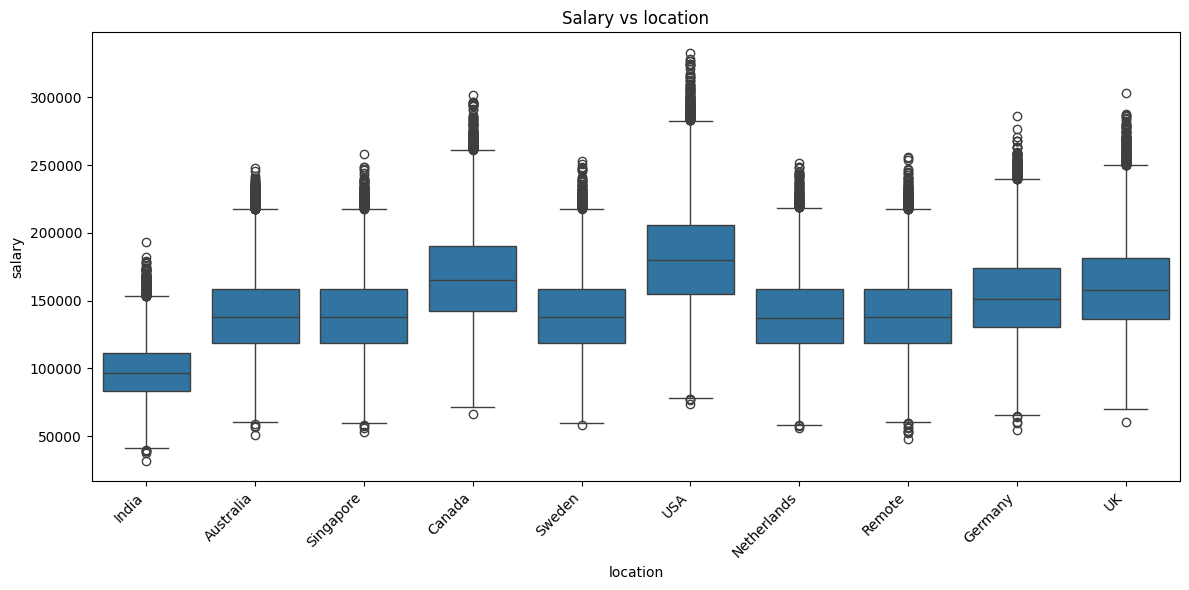

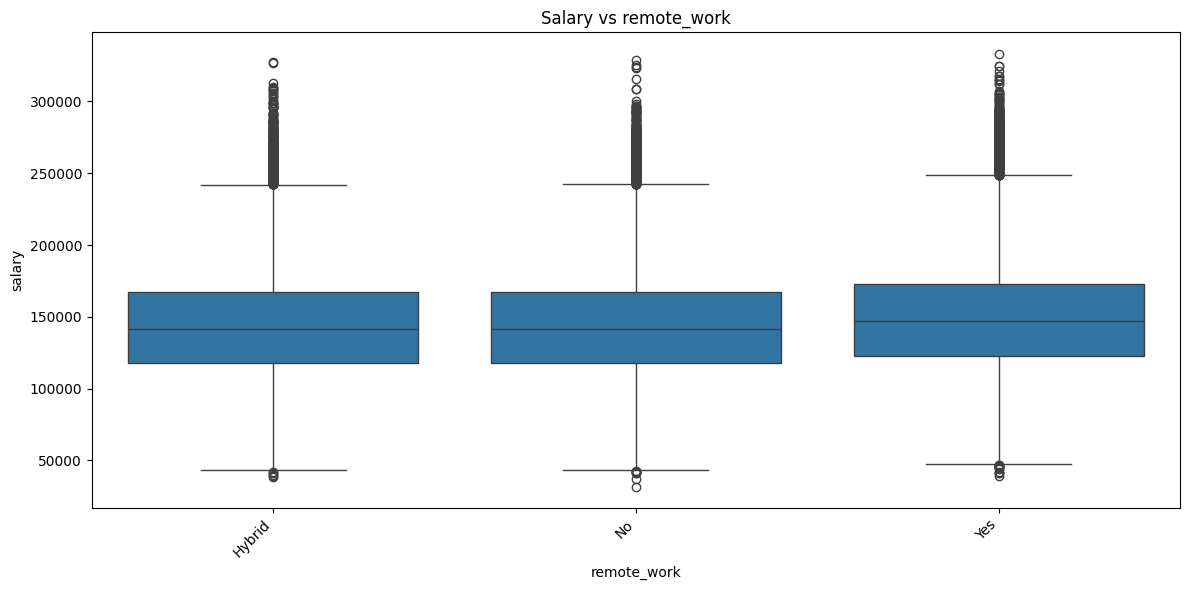

In [11]:
for col in cols:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

for col in cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x=col, y='salary')
    plt.title(f'Salary vs {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

#### Train/Test Split

In [12]:
x = df.drop("salary", axis=1)
y = df["salary"]

In [13]:
x = pd.get_dummies(x, drop_first=True, dtype=int)

print(x.shape)

x.head(1)

(250000, 42)


,experience_years,skills_count,certifications,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,job_title_DevOps Engineer,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42
)

print("Train shape:", x_train.shape, "Test shape:", x_test.shape)

Train shape: (200000, 42) Test shape: (50000, 42)


In [ ]:
def adjusted_r2()